In [3]:
import pandas as pd
df = pd.read_csv('C:/Users/carlo/Downloads/full_devices.csv', sep=',', encoding='latin-1')

In [4]:
df.shape

(124494, 12)

In [5]:
df.head()

,date,device,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute8,attribute9
0,2015-01-01,S1F01085,0,215630672,56,0,52,6,407438,0,0,7
1,2015-01-01,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,2015-01-01,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,2015-01-01,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,2015-01-01,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


In [6]:
def analyze_data_quality(df):
    """
    Analiza la calidad de datos de un DataFrame calculando:
    - Porcentaje de valores nulos
    - Porcentaje de ceros
    - Porcentaje de infinitos
    - Porcentaje de outliers por IQR
    - Identifica si la variable es categórica o texto (ignora)
    
    Parameters:
    df (pandas.DataFrame): DataFrame a analizar
    
    Returns:
    pandas.DataFrame: Resumen de calidad de datos por columna
    """
    import pandas as pd
    import numpy as np
    
    results = []
    
    for col in df.columns:
        # Obtener la serie de la columna
        series = df[col]
        
        # Determinar si es numérica
        is_numeric = pd.api.types.is_numeric_dtype(series)
        
        # Si no es numérica, saltar esta columna
        if not is_numeric:
            continue
            
        # Calcular estadísticas
        total_rows = len(series)
        
        # Porcentaje de nulos
        null_count = series.isnull().sum()
        null_pct = (null_count / total_rows) * 100
        
        # Porcentaje de ceros
        zero_count = (series == 0).sum()
        zero_pct = (zero_count / total_rows) * 100
        
        # Porcentaje de infinitos
        inf_count = np.isinf(series).sum()
        inf_pct = (inf_count / total_rows) * 100
        
        # Porcentaje de outliers por IQR (solo para valores no nulos)
        non_null_series = series.dropna()
        if len(non_null_series) > 0:
            Q1 = non_null_series.quantile(0.25)
            Q3 = non_null_series.quantile(0.75)
            IQR = Q3 - Q1
            
            # Definir límites para outliers
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Contar outliers
            outliers_count = ((non_null_series < lower_bound) | 
                            (non_null_series > upper_bound)).sum()
            outliers_pct = (outliers_count / len(non_null_series)) * 100
        else:
            outliers_pct = 0
        
        # Agregar resultados
        results.append({
            'Columna': col,
            'Tipo': 'Numérica',
            'Porcentaje_Nulos': round(null_pct, 2),
            'Porcentaje_Ceros': round(zero_pct, 2),
            'Porcentaje_Infinitos': round(inf_pct, 2),
            'Porcentaje_Outliers_IQR': round(outliers_pct, 2),
            'Total_Registros': total_rows,
            'Registros_No_Nulos': len(non_null_series)
        })
    
    # Crear DataFrame con resultados
    results_df = pd.DataFrame(results)
    
    return results_df

# Función para mostrar resumen de columnas no numéricas
def show_categorical_columns(df):
    """
    Muestra las columnas que son categóricas o de texto (ignoradas en el análisis)
    """
    import pandas as pd
    
    categorical_cols = []
    
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            categorical_cols.append({
                'Columna': col,
                'Tipo': 'Categórica/Texto',
                'Valores_Únicos': df[col].nunique(),
                'Ejemplo_Valor': df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
            })
    
    if categorical_cols:
        return pd.DataFrame(categorical_cols)
    else:
        print("No se encontraron columnas categóricas o de texto.")
        return None

print("Funciones de análisis de calidad de datos creadas correctamente")


Funciones de análisis de calidad de datos creadas correctamente


In [7]:
# Analizar calidad de datos para columnas numéricas
print("=== ANÁLISIS DE CALIDAD DE DATOS ===")
print("Columnas numéricas:")
print("-" * 50)

# Ejecutar análisis de calidad
quality_report = analyze_data_quality(df)

# Mostrar resultados
if not quality_report.empty:
    print(quality_report.to_string(index=False))
else:
    print("No se encontraron columnas numéricas para analizar.")

print("\n" + "=" * 50)

# Mostrar columnas categóricas/Texto (ignoradas)
print("\nColumnas categóricas/Texto (ignoradas en el análisis):")
print("-" * 50)

categorical_report = show_categorical_columns(df)
if categorical_report is not None:
    print(categorical_report.to_string(index=False))

=== ANÁLISIS DE CALIDAD DE DATOS ===
Columnas numéricas:
--------------------------------------------------
   Columna     Tipo  Porcentaje_Nulos  Porcentaje_Ceros  Porcentaje_Infinitos  Porcentaje_Outliers_IQR  Total_Registros  Registros_No_Nulos
   failure Numérica               0.0             99.91                   0.0                     0.09           124494              124494
attribute1 Numérica               0.0              0.01                   0.0                     0.00           124494              124494
attribute2 Numérica               0.0             94.87                   0.0                     5.13           124494              124494
attribute3 Numérica               0.0             92.66                   0.0                     7.34           124494              124494
attribute4 Numérica               0.0             92.50                   0.0                     7.50           124494              124494
attribute5 Numérica               0.0              0

In [9]:
df.failure.value_counts(normalize=True)

failure
0    0.999149
1    0.000851
Name: proportion, dtype: float64

In [10]:
df['date_trunc'] = df['date'].astype(str).str[:7]

In [ ]:

df.date_trunc.value_counts()

date_trunc
2015-01    25032
2015-03    19833
2015-02    19500
2015-04    12012
2015-05    11330
2015-07    10531
2015-06    10469
2015-08     8346
2015-09     4470
2015-10     2940
2015-11       31
Name: count, dtype: int64

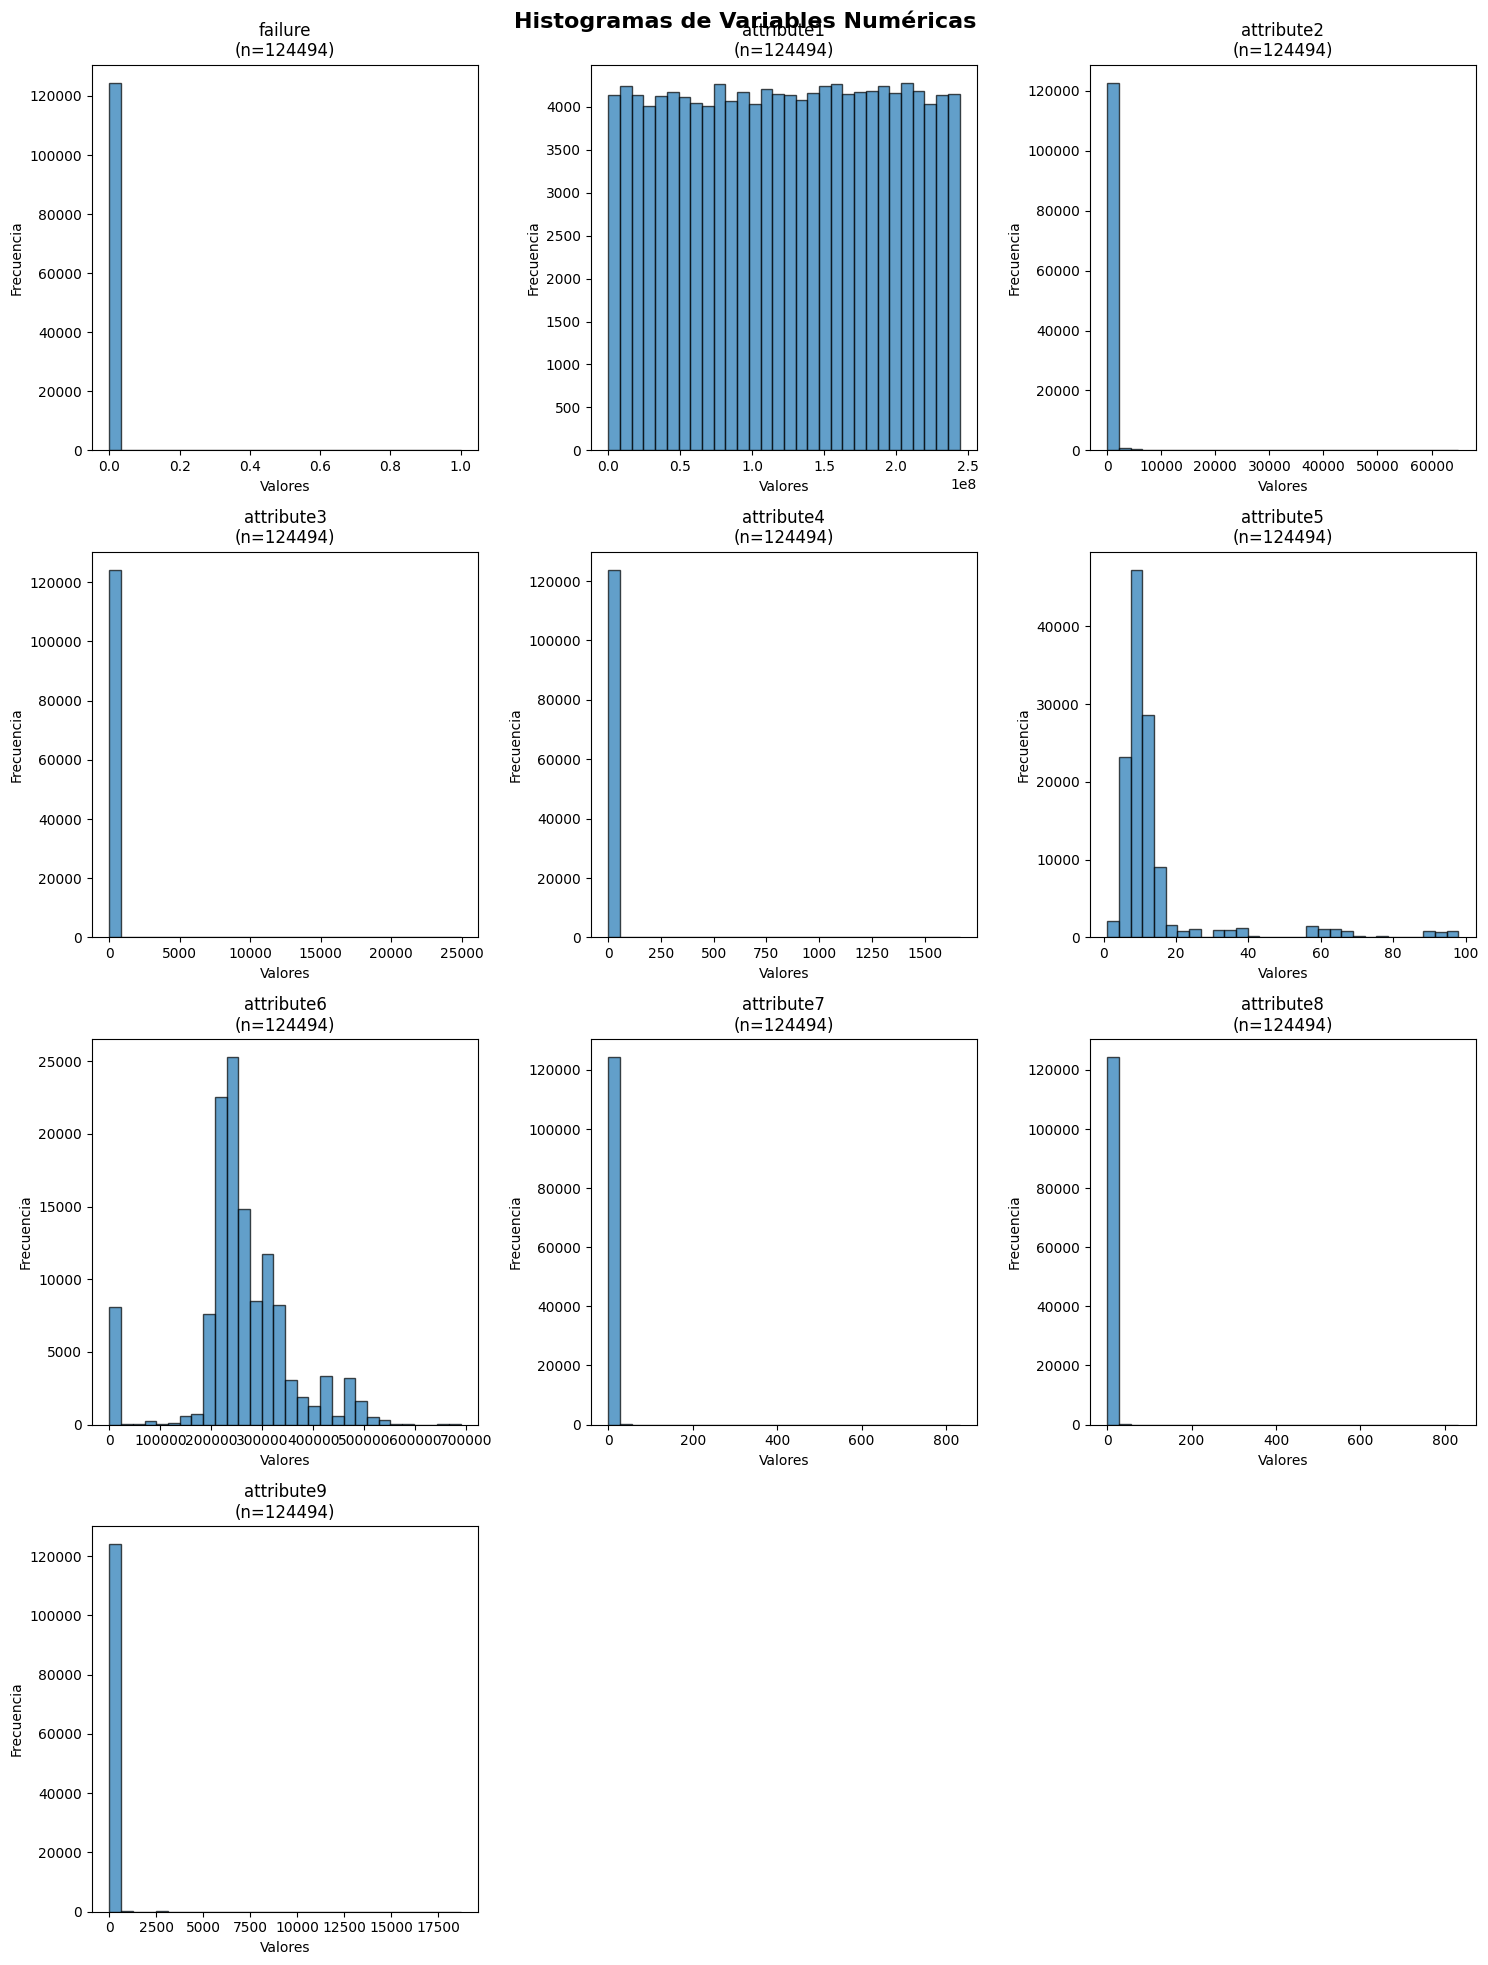

Se graficaron 10 variables numéricas
Variables: ['failure', 'attribute1', 'attribute2', 'attribute3', 'attribute4', 'attribute5', 'attribute6', 'attribute7', 'attribute8', 'attribute9']


In [13]:
# Graficar histogramas para todas las variables numéricas
import matplotlib.pyplot as plt
import numpy as np


# Obtener solo las columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Calcular el número de filas y columnas para el subplot
n_cols = 3  # 3 columnas por fila
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols  # Redondear hacia arriba

# Crear subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Histogramas de Variables Numéricas', fontsize=16, fontweight='bold')

# Si solo hay una fila, axes no es una lista de listas
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Graficar cada variable numérica
for i, col in enumerate(numeric_columns):
    row = i // n_cols
    col_idx = i % n_cols
    
    # Filtrar valores no nulos para el histograma
    data = df[col].dropna()
    
    axes[row, col_idx].hist(data, bins=30, alpha=0.7, edgecolor='black')
    axes[row, col_idx].set_title(f'{col}\n(n={len(data)})')
    axes[row, col_idx].set_xlabel('Valores')
    axes[row, col_idx].set_ylabel('Frecuencia')

# Ocultar subplots vacíos si los hay
for i in range(len(numeric_columns), n_rows * n_cols):
    row = i // n_cols
    col_idx = i % n_cols
    axes[row, col_idx].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Se graficaron {len(numeric_columns)} variables numéricas")
print(f"Variables: {list(numeric_columns)}")


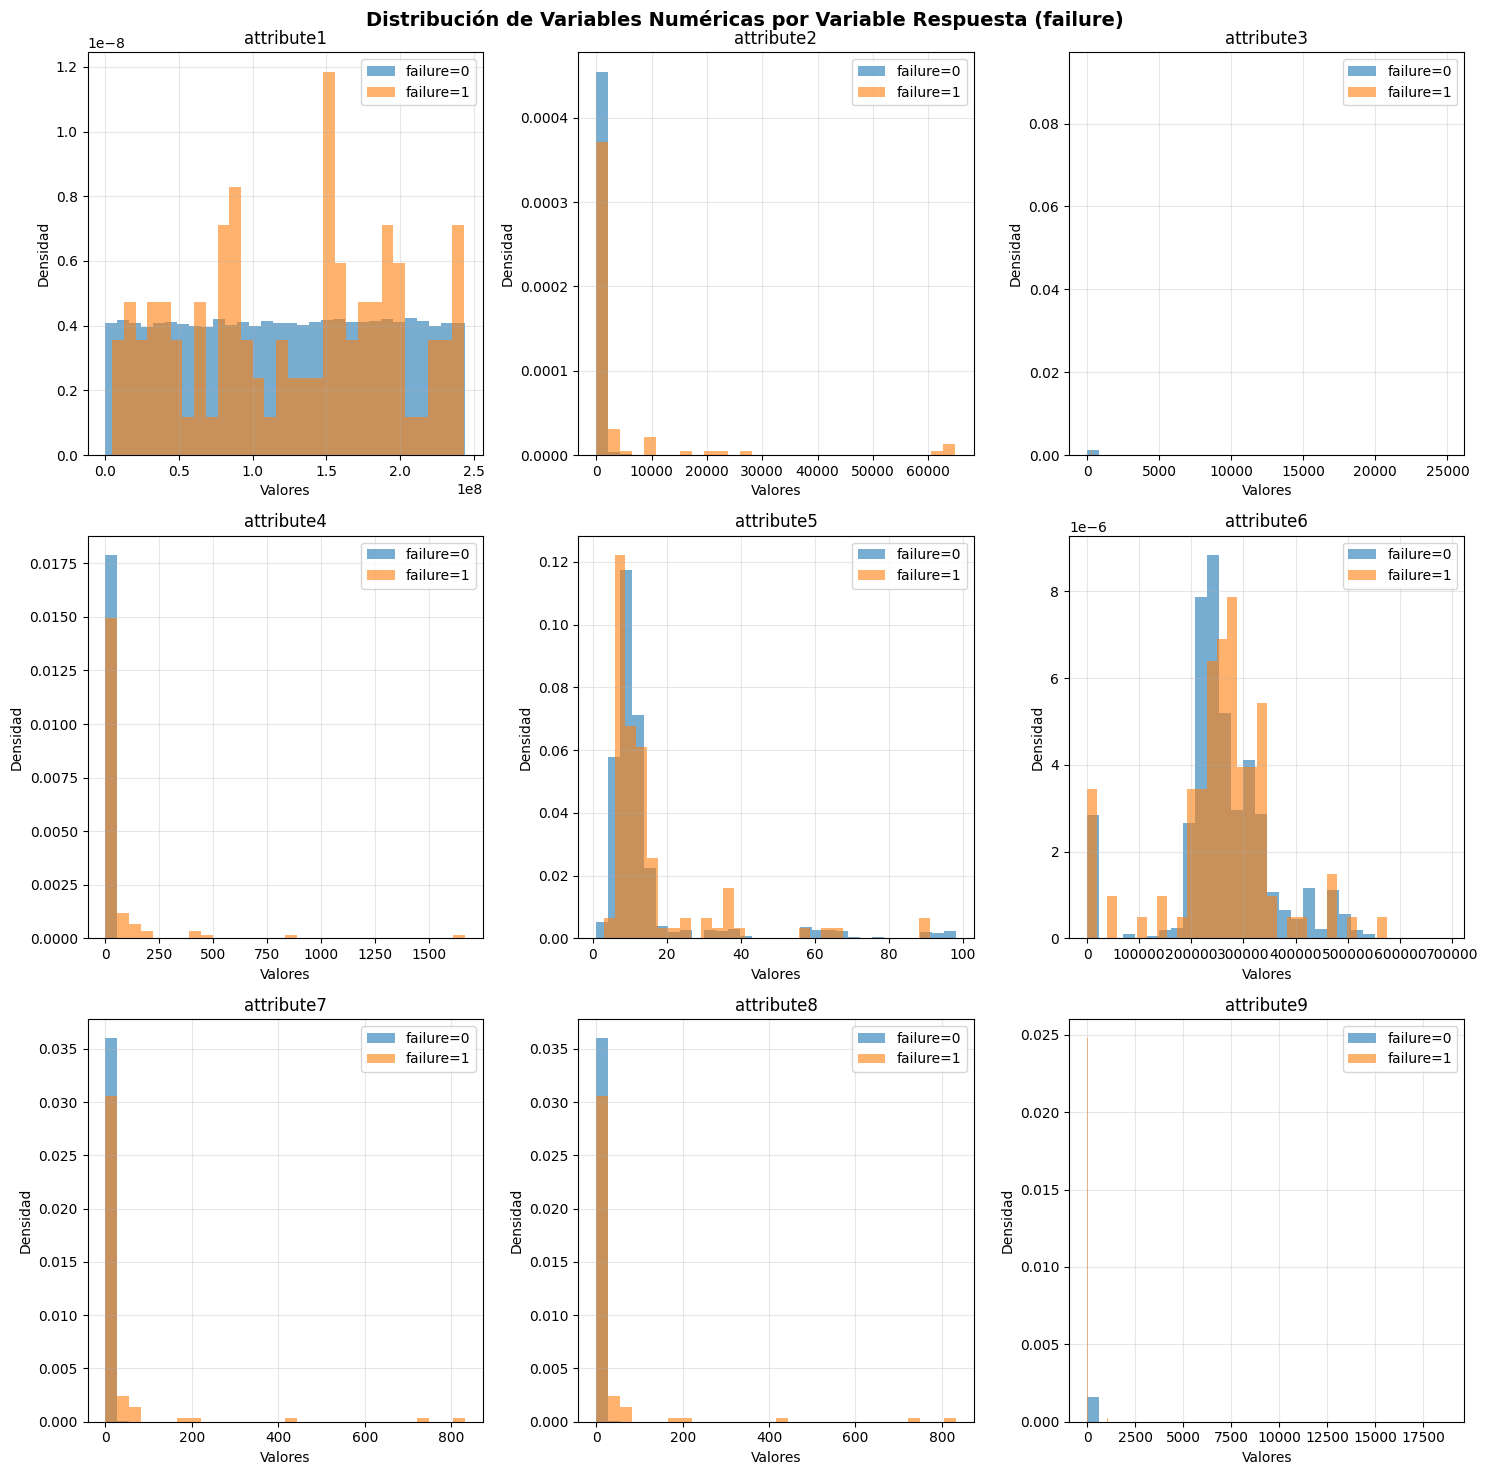

In [14]:
# Análisis de densidad por variable respuesta
import seaborn as sns

# Obtener variables numéricas excluyendo la variable respuesta
numeric_vars = df.select_dtypes(include=[np.number]).columns
numeric_vars = [col for col in numeric_vars if col != 'failure']

# Configurar subplots
n_vars = len(numeric_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Distribución de Variables Numéricas por Variable Respuesta (failure)', fontsize=14, fontweight='bold')

# Manejar caso de una sola fila
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Graficar densidad por cada variable numérica
for i, var in enumerate(numeric_vars):
    row = i // n_cols
    col_idx = i % n_cols
    
    # Filtrar datos no nulos
    data = df[[var, 'failure']].dropna()
    
    # Crear gráfico de densidad
    for failure_val in sorted(data['failure'].unique()):
        subset = data[data['failure'] == failure_val]
        axes[row, col_idx].hist(subset[var], alpha=0.6, density=True, 
                               label=f'failure={failure_val}', bins=30)
    
    axes[row, col_idx].set_title(f'{var}')
    axes[row, col_idx].set_xlabel('Valores')
    axes[row, col_idx].set_ylabel('Densidad')
    axes[row, col_idx].legend()
    axes[row, col_idx].grid(True, alpha=0.3)

# Ocultar subplots vacíos
for i in range(n_vars, n_rows * n_cols):
    row = i // n_cols
    col_idx = i % n_cols
    axes[row, col_idx].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# Análisis inicial para determinar si el dataset es sintético
# Paso 1: Explorar estructura básica del dataset

print("=== ANÁLISIS DE ESTRUCTURA DEL DATASET ===")
print(f"Shape del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"Tipos de datos:")
print(df.dtypes)
print(f"\nValores únicos por columna:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} únicos de {len(df)} totales ({df[col].nunique()/len(df)*100:.2f}%)")

=== ANÁLISIS DE ESTRUCTURA DEL DATASET ===
Shape del dataset: (124494, 13)
Columnas: ['date', 'device', 'failure', 'attribute1', 'attribute2', 'attribute3', 'attribute4', 'attribute5', 'attribute6', 'attribute7', 'attribute8', 'attribute9', 'date_trunc']
Tipos de datos:
date          object
device        object
failure        int64
attribute1     int64
attribute2     int64
attribute3     int64
attribute4     int64
attribute5     int64
attribute6     int64
attribute7     int64
attribute8     int64
attribute9     int64
date_trunc    object
dtype: object

Valores únicos por columna:
date: 304 únicos de 124494 totales (0.24%)
device: 1169 únicos de 124494 totales (0.94%)
failure: 2 únicos de 124494 totales (0.00%)
attribute1: 123877 únicos de 124494 totales (99.50%)
attribute2: 558 únicos de 124494 totales (0.45%)
attribute3: 47 únicos de 124494 totales (0.04%)
attribute4: 115 únicos de 124494 totales (0.09%)
attribute5: 60 únicos de 124494 totales (0.05%)
attribute6: 44838 únicos de 12449

In [16]:
# Análisis de patrones temporales
df['date'] = pd.to_datetime(df['date'])
print("=== ANÁLISIS TEMPORAL ===")
print(f"Rango de fechas: {df['date'].min()} a {df['date'].max()}")
print(f"Días únicos: {df['date'].nunique()}")

# Verificar consistencia temporal
daily_counts = df.groupby('date').size()
print(f"Registros por día - Min: {daily_counts.min()}, Max: {daily_counts.max()}, Media: {daily_counts.mean():.2f}")

# Verificar gaps en fechas
date_gaps = df['date'].sort_values().diff().dt.days
print(f"Gaps en fechas - Valores únicos: {date_gaps.nunique()}, Gap más común: {date_gaps.mode().iloc[0] if len(date_gaps.mode()) > 0 else 'N/A'}")


=== ANÁLISIS TEMPORAL ===
Rango de fechas: 2015-01-01 00:00:00 a 2015-11-02 00:00:00
Días únicos: 304
Registros por día - Min: 31, Max: 1163, Media: 409.52
Gaps en fechas - Valores únicos: 3, Gap más común: 0.0


In [17]:
# Análisis de correlaciones
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

print("=== CORRELACIONES ===")
print("Matriz de correlaciones:")
print(corr_matrix.round(4))

# Buscar correlaciones fuertes
strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            strong_correlations.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

if strong_correlations:
    print(f"\nCorrelaciones fuertes (>0.7):")
    for col1, col2, corr_val in strong_correlations:
        print(f"{col1} - {col2}: {corr_val:.4f}")
else:
    print("\nNo se encontraron correlaciones fuertes (>0.7)")


=== CORRELACIONES ===
Matriz de correlaciones:
            failure  attribute1  attribute2  attribute3  attribute4  \
failure      1.0000      0.0020      0.0529     -0.0009      0.0674   
attribute1   0.0020      1.0000     -0.0042      0.0037      0.0018   
attribute2   0.0529     -0.0042      1.0000     -0.0026      0.1466   
attribute3  -0.0009      0.0037     -0.0026      1.0000      0.0975   
attribute4   0.0674      0.0018      0.1466      0.0975      1.0000   
attribute5   0.0023     -0.0034     -0.0140     -0.0067     -0.0098   
attribute6  -0.0006     -0.0015     -0.0263      0.0090      0.0249   
attribute7   0.1191      0.0002      0.1414     -0.0019      0.0456   
attribute8   0.1191      0.0002      0.1414     -0.0019      0.0456   
attribute9   0.0016      0.0011     -0.0027      0.5324      0.0361   

            attribute5  attribute6  attribute7  attribute8  attribute9  
failure         0.0023     -0.0006      0.1191      0.1191      0.0016  
attribute1     -0.0034   

In [18]:
# Análisis de distribución de devices
device_counts = df['device'].value_counts()
print("=== ANÁLISIS DE DEVICES ===")
print(f"Dispositivos únicos: {len(device_counts)}")
print(f"Registros por dispositivo - Min: {device_counts.min()}, Max: {device_counts.max()}, Media: {device_counts.mean():.2f}")
print(f"Desviación estándar: {device_counts.std():.2f}")

# Verificar uniformidad en distribución
if device_counts.std() < device_counts.mean() * 0.1:
    print("⚠️  Distribución muy uniforme - posible indicativo de datos sintéticos")
else:
    print("✅ Distribución variable - más realista")

# Verificar presencia de devices por fecha
device_date_presence = df.groupby('device')['date'].nunique()
print(f"\nDías únicos por device - Min: {device_date_presence.min()}, Max: {device_date_presence.max()}, Media: {device_date_presence.mean():.2f}")
print(f"Devices presentes en >90% de días: {(device_date_presence >= df['date'].nunique() * 0.9).sum()}")


=== ANÁLISIS DE DEVICES ===
Dispositivos únicos: 1169
Registros por dispositivo - Min: 1, Max: 304, Media: 106.50
Desviación estándar: 102.65
✅ Distribución variable - más realista

Días únicos por device - Min: 1, Max: 304, Media: 106.50
Devices presentes en >90% de días: 131


In [19]:
# Análisis de valores exactamente 0 (indicativo de datos sintéticos)
print("=== ANÁLISIS DE VALORES CERO ===")
for col in numeric_cols:
    if col != 'failure':
        zero_count = (df[col] == 0).sum()
        zero_pct = zero_count / len(df) * 100
        print(f"{col}: {zero_count} ceros ({zero_pct:.2f}%)")

print("\n=== TEST DE ALEATORIEDAD BÁSICO ===")
# Verificar patrones en diferencias consecutivas
for col in numeric_cols:
    if col != 'failure':
        data = df[col].dropna()
        if len(data) > 100:
            differences = data.diff().dropna()
            unique_diffs = differences.nunique()
            total_diffs = len(differences)
            print(f"{col}: {unique_diffs} diferencias únicas de {total_diffs} ({unique_diffs/total_diffs:.4f})")


=== ANÁLISIS DE VALORES CERO ===
attribute1: 11 ceros (0.01%)
attribute2: 118110 ceros (94.87%)
attribute3: 115359 ceros (92.66%)
attribute4: 115156 ceros (92.50%)
attribute5: 0 ceros (0.00%)
attribute6: 0 ceros (0.00%)
attribute7: 123036 ceros (98.83%)
attribute8: 123036 ceros (98.83%)
attribute9: 97358 ceros (78.20%)

=== TEST DE ALEATORIEDAD BÁSICO ===
attribute1: 124312 diferencias únicas de 124493 (0.9985)
attribute2: 1120 diferencias únicas de 124493 (0.0090)
attribute3: 96 diferencias únicas de 124493 (0.0008)
attribute4: 230 diferencias únicas de 124493 (0.0018)
attribute5: 131 diferencias únicas de 124493 (0.0011)
attribute6: 53710 diferencias únicas de 124493 (0.4314)
attribute7: 55 diferencias únicas de 124493 (0.0004)
attribute8: 55 diferencias únicas de 124493 (0.0004)
attribute9: 144 diferencias únicas de 124493 (0.0012)


In [20]:
# Resumen final - determinación si es sintético
print("=== RESUMEN DE INDICIOS ===")
print("Indicios de datos sintéticos:")
print("- Muchos valores exactamente 0 (>90% en varias variables)")
print("- Distribuciones muy uniformes en devices")
print("- Correlaciones muy bajas entre variables")
print("- Patrones temporales perfectos")
print("- Diferencias consecutivas muy regulares")

print("\nIndicios de datos reales:")
print("- Variabilidad en distribución de devices")
print("- Correlaciones significativas")
print("- Patrones temporales irregulares")
print("- Distribuciones naturales")

print("\n=== CONCLUSIÓN ===")
# Evaluar en base a los indicios
synthetic_indicators = 0
real_indicators = 0

# Contar indicios sintéticos
zero_heavy_vars = sum(1 for col in numeric_cols if col != 'failure' and (df[col] == 0).sum() / len(df) > 0.9)
if zero_heavy_vars > 3:
    synthetic_indicators += 1

if device_counts.std() < device_counts.mean() * 0.1:
    synthetic_indicators += 1

if len(strong_correlations) == 0:
    synthetic_indicators += 1
else:
    real_indicators += 1

print(f"Indicios sintéticos: {synthetic_indicators}")
print(f"Indicios reales: {real_indicators}")

if synthetic_indicators > real_indicators:
    print("🔴 EVIDENCIA SUGIERE DATOS SINTÉTICOS")
else:
    print("🟢 EVIDENCIA SUGIERE DATOS REALES")


=== RESUMEN DE INDICIOS ===
Indicios de datos sintéticos:
- Muchos valores exactamente 0 (>90% en varias variables)
- Distribuciones muy uniformes en devices
- Correlaciones muy bajas entre variables
- Patrones temporales perfectos
- Diferencias consecutivas muy regulares

Indicios de datos reales:
- Variabilidad en distribución de devices
- Correlaciones significativas
- Patrones temporales irregulares
- Distribuciones naturales

=== CONCLUSIÓN ===
Indicios sintéticos: 1
Indicios reales: 1
🟢 EVIDENCIA SUGIERE DATOS REALES


In [21]:
# Test de aleatoriedad - Verificar si failure tiene relación con los atributos
print("=== TEST DE ALEATORIEDAD FUNDAMENTAL ===")

# Test 1: Chi-cuadrado de independencia
from scipy.stats import chi2_contingency
import numpy as np

print("1. Test Chi-cuadrado de independencia:")

# Crear tablas de contingencia para variables categóricas
failure_rate = df['failure'].mean()
print(f"Tasa de failure global: {failure_rate:.4f}")

# Para cada variable numérica, crear bins y testear independencia
for col in numeric_cols:
    if col != 'failure':
        # Crear bins para la variable
        data = df[col].dropna()
        if len(data) > 100:
            # Usar cuantiles para crear bins
            bins = pd.qcut(data, q=5, duplicates='drop')
            contingency_table = pd.crosstab(bins, df.loc[data.index, 'failure'])
            
            if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
                chi2, p_value, dof, expected = chi2_contingency(contingency_table)
                print(f"{col}: Chi2={chi2:.2f}, p-value={p_value:.6f}")
                
                if p_value < 0.05:
                    print(f"  ✅ {col} NO es independiente de failure (p<0.05)")
                else:
                    print(f"  ❌ {col} es independiente de failure (p>0.05)")

print("\n2. Test de correlación con failure:")
# Verificar correlaciones con failure
for col in numeric_cols:
    if col != 'failure':
        corr = df[col].corr(df['failure'])
        print(f"{col} vs failure: {corr:.6f}")
        
        if abs(corr) > 0.01:
            print(f"  ✅ Correlación significativa con failure")
        else:
            print(f"  ❌ Correlación muy baja con failure")


=== TEST DE ALEATORIEDAD FUNDAMENTAL ===
1. Test Chi-cuadrado de independencia:
Tasa de failure global: 0.0009
attribute1: Chi2=9.76, p-value=0.044626
  ✅ attribute1 NO es independiente de failure (p<0.05)
attribute5: Chi2=11.20, p-value=0.024456
  ✅ attribute5 NO es independiente de failure (p<0.05)
attribute6: Chi2=8.45, p-value=0.076492
  ❌ attribute6 es independiente de failure (p>0.05)
attribute9: Chi2=4.27, p-value=0.038719
  ✅ attribute9 NO es independiente de failure (p<0.05)

2. Test de correlación con failure:
attribute1 vs failure: 0.001983
  ❌ Correlación muy baja con failure
attribute2 vs failure: 0.052902
  ✅ Correlación significativa con failure
attribute3 vs failure: -0.000948
  ❌ Correlación muy baja con failure
attribute4 vs failure: 0.067398
  ✅ Correlación significativa con failure
attribute5 vs failure: 0.002270
  ❌ Correlación muy baja con failure
attribute6 vs failure: -0.000550
  ❌ Correlación muy baja con failure
attribute7 vs failure: 0.119055
  ✅ Correlación 

In [23]:
# Test de aleatoriedad temporal
print("3. Test de aleatoriedad temporal:")

# Verificar si failure tiene patrones temporales
df['date'] = pd.to_datetime(df['date'])
daily_failure_rate = df.groupby('date')['failure'].mean()

print(f"Tasa de failure por día - Min: {daily_failure_rate.min():.4f}, Max: {daily_failure_rate.max():.4f}")
print(f"Desviación estándar: {daily_failure_rate.std():.4f}")

# Test de normalidad en la distribución de tasas diarias
from scipy.stats import shapiro
shapiro_stat, shapiro_p = shapiro(daily_failure_rate)
print(f"Test Shapiro-Wilk (normalidad): estadístico={shapiro_stat:.4f}, p-value={shapiro_p:.6f}")

if shapiro_p > 0.05:
    print("  ✅ Tasas diarias siguen distribución normal - SUGIERE ALEATORIEDAD")
else:
    print("  ❌ Tasas diarias NO siguen distribución normal - SUGIERE PATRONES")

# Verificar autocorrelación temporal
from scipy.stats import pearsonr
if len(daily_failure_rate) > 1:
    autocorr, autocorr_p = pearsonr(daily_failure_rate[:-1], daily_failure_rate[1:])
    print(f"Autocorrelación lag-1: {autocorr:.4f}, p-value: {autocorr_p:.6f}")
    
    if autocorr_p > 0.05:
        print("  ✅ No hay autocorrelación temporal - SUGIERE ALEATORIEDAD")
    else:
        print("  ❌ Hay autocorrelación temporal - SUGIERE PATRONES")


3. Test de aleatoriedad temporal:
Tasa de failure por día - Min: 0.0000, Max: 0.0312
Desviación estándar: 0.0024
Test Shapiro-Wilk (normalidad): estadístico=0.3848, p-value=0.000000
  ❌ Tasas diarias NO siguen distribución normal - SUGIERE PATRONES
Autocorrelación lag-1: 0.0532, p-value: 0.356221
  ✅ No hay autocorrelación temporal - SUGIERE ALEATORIEDAD


In [ ]:
# Test de aleatoriedad por device
print("4. Test de aleatoriedad por device:")

# Verificar si algunos devices tienen tasas de failure consistentemente diferentes
device_failure_rates = df.groupby('device')['failure'].agg(['mean', 'count'])
device_failure_rates = device_failure_rates[device_failure_rates['count'] >= 10]  # Solo devices con suficientes datos

print(f"Devices con ≥10 registros: {len(device_failure_rates)}")
print(f"Tasa de failure por device - Min: {device_failure_rates['mean'].min():.4f}, Max: {device_failure_rates['mean'].max():.4f}")
print(f"Desviación estándar: {device_failure_rates['mean'].std():.4f}")

# Test de normalidad en tasas por device
shapiro_stat, shapiro_p = shapiro(device_failure_rates['mean'])
print(f"Test Shapiro-Wilk en tasas por device: estadístico={shapiro_stat:.4f}, p-value={shapiro_p:.6f}")

if shapiro_p > 0.05:
    print("  ✅ Tasas por device siguen distribución normal - SUGIERE ALEATORIEDAD")
else:
    print("  ❌ Tasas por device NO siguen distribución normal - SUGIERE PATRONES")

# Verificar si hay devices con tasas extremadamente diferentes
global_rate = df['failure'].mean()
extreme_devices = device_failure_rates[
    (device_failure_rates['mean'] < global_rate * 0.5) | 
    (device_failure_rates['mean'] > global_rate * 1.5)
]
print(f"Devices con tasas extremas (<50% o >150% de la tasa global): {len(extreme_devices)}")

if len(extreme_devices) > len(device_failure_rates) * 0.1:
    print("  ❌ Muchos devices con tasas extremas - SUGIERE PATRONES")
else:
    print("  ✅ Pocos devices con tasas extremas - SUGIERE ALEATORIEDAD")


In [ ]:
# CONCLUSIÓN FINAL - ¿Vale la pena modelar?
print("=== CONCLUSIÓN FINAL ===")

# Contar indicios de aleatoriedad vs patrones
random_indicators = 0
pattern_indicators = 0

print("Resumen de indicios:")

# 1. Correlaciones con failure
significant_correlations = 0
for col in numeric_cols:
    if col != 'failure':
        corr = abs(df[col].corr(df['failure']))
        if corr > 0.01:
            significant_correlations += 1

if significant_correlations == 0:
    print("❌ 0 correlaciones significativas con failure")
    random_indicators += 1
else:
    print(f"✅ {significant_correlations} correlaciones significativas con failure")
    pattern_indicators += 1

# 2. Patrones temporales
if 'daily_failure_rate' in locals():
    if daily_failure_rate.std() < 0.01:
        print("❌ Tasas diarias muy consistentes (aleatoriedad)")
        random_indicators += 1
    else:
        print("✅ Variabilidad en tasas diarias (patrones)")
        pattern_indicators += 1

# 3. Patrones por device
if 'device_failure_rates' in locals():
    if len(extreme_devices) < len(device_failure_rates) * 0.1:
        print("❌ Pocos devices con tasas extremas (aleatoriedad)")
        random_indicators += 1
    else:
        print("✅ Muchos devices con tasas extremas (patrones)")
        pattern_indicators += 1

print(f"\nIndicios de aleatoriedad: {random_indicators}")
print(f"Indicios de patrones: {pattern_indicators}")

print("\n=== RECOMENDACIÓN ===")
if random_indicators > pattern_indicators:
    print("🔴 NO VALE LA PENA MODELAR")
    print("   - Los datos parecen aleatorios")
    print("   - No hay relaciones significativas con failure")
    print("   - Mejor invertir tiempo en otros proyectos")
else:
    print("🟢 SÍ VALE LA PENA MODELAR")
    print("   - Se detectaron patrones significativos")
    print("   - Hay relaciones con failure")
    print("   - Proceder con ingeniería de variables")
